# SIT374/SIT764 Capstone Team Project
### Jack Montgomery-Parkes :: S223232288@deakin.edu.au
## Project Echo Benchmarking

This notebook was written for Trimester 1, 2026. We were tasked with benchmarking three candidate model architectures for the Project Echo Engine:

- **GhostNet**
- **EfficientNetV2**
- **PANNs CNN14**

A simple **Logistic Regression** baseline is also included first in order establish a floor before the deep models.

As an extension and proof of concept, I've extended the original Notebook I used to benchmark Project Echo with four additional models, including one vision transformer model. 

- **ConvNeXt**
- **ViT**
- **ResNet**
- **MobileNet**

The goal for this extension was both to demonstrate how benchmark setups should be created, reusing as much of the environment as physically possible in order to best compare each model, and also to provide an entry point to new students within the Project Echo Engine team. This, combined with the companion Notebook on Audio in Machine Learning should cover the intuition grounds of working with audio within a Machine Learning and Deep Learning context, from the perspective of a sound engineer fascinated by ML models, generally. Enjoy!


## Environment Setup

Install everything in one go. `librosa` is pinned to 0.9.2 for compatibility with `panns-inference`; if you already have a different version, this may force a downgrade.


In [ ]:
# !pip install librosa==0.9.2 panns-inference timm thop scikit-learn tqdm


## Notebook Setup

Standard imports. `warnings` is silenced to keep the output sane.


In [38]:
import time, pathlib, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import librosa

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import timm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, top_k_accuracy_score,
    confusion_matrix, classification_report,
)
from sklearn.linear_model import LogisticRegression

from thop import profile as thop_profile

print("Modules loaded.")


Modules loaded.


### Configuration

Edit `DATA_ROOT` to point at your audio folder. Subfolders are our class labels. Pick the `DEVICE` line that matches your system.


In [39]:
# EDIT this to point at your local audio folder:
DATA_ROOT = pathlib.Path(r"/Users/jack/Documents/Deakin/SIT374/Tasks/data")

# Audio feature settings
VALID_EXTS = {".wav", ".mp3", ".flac", ".ogg"}
TARGET_SR = 32000  # 32k gives us a Nyquist at 16k (just below the threshold of hearing for normal humans)
DURATION_S = 5.0  # crop/pad clips to max 5 secs
N_MELS = 128
HOP_LENGTH = 512
FMIN, FMAX = 20, 14000

# Split and train settings
TEST_SIZE = 0.3
RANDOM_STATE = 42
NUM_EPOCHS = 10
BATCH_SIZE = 16

# Pick the device that matches your machine
# DEVICE = "cuda"  # NVIDIA GPU
DEVICE = "mps"  # Apple Silicon
# DEVICE = "cpu"  # CPU fallback (slow)

CACHE_DIR = DATA_ROOT / "_feature_cache"
CACHE_DIR.mkdir(exist_ok=True)

print("Config set.")


Config set.


### Load Your Dataset

Scan `DATA_ROOT` for audio files. Each subfolder is one class.


In [37]:
def scan_audio(root):
    rows = []
    for species_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        for f in species_dir.iterdir():
            if f.is_file() and f.suffix.lower() in VALID_EXTS:
                rows.append({"path": str(f), "label": species_dir.name})
    return pd.DataFrame(rows)

files_df = scan_audio(DATA_ROOT)
print(f"Found {len(files_df)} files across {files_df['label'].nunique()} classes.")
files_df.head()


Found 8659 files across 123 classes.


,path,label
0,/Users/jack/Documents/Deakin/SIT374/Tasks/data...,Acanthiza chrysorrhoa
1,/Users/jack/Documents/Deakin/SIT374/Tasks/data...,Acanthiza chrysorrhoa
2,/Users/jack/Documents/Deakin/SIT374/Tasks/data...,Acanthiza chrysorrhoa
3,/Users/jack/Documents/Deakin/SIT374/Tasks/data...,Acanthiza chrysorrhoa
4,/Users/jack/Documents/Deakin/SIT374/Tasks/data...,Acanthiza chrysorrhoa


### Feature Extraction

For each audio clip we load it at a fixed sample rate, crop/pad to a fixed length, and compute a log-Mel spectrogram with `librosa`. Results are cached as `.npy` files so we only do this work once.


In [40]:
def load_audio(path):
    """Load mono audio, crop/pad to DURATION_S * TARGET_SR samples."""
    y, _ = librosa.load(path, sr=TARGET_SR, mono=True)
    target_len = int(DURATION_S * TARGET_SR)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    return y[:target_len]

def melspec(y):
    """Log-Mel spectrogram, shape [N_MELS, T]."""
    S = librosa.feature.melspectrogram(
        y=y, sr=TARGET_SR, n_mels=N_MELS,
        hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX
    )
    return librosa.power_to_db(S, ref=np.max).astype(np.float32)

def cached_feature(audio_path):
    """Return the Mel spectrogram, computing and caching it on first use."""
    cache_file = CACHE_DIR / (pathlib.Path(audio_path).stem + ".npy")
    if cache_file.exists():
        return np.load(cache_file)
    feat = melspec(load_audio(audio_path))
    np.save(cache_file, feat)
    return feat

print("Feature helpers defined.")


Feature helpers defined.


### Encode Labels & Pre-cache Features

We use `sklearn.preprocessing.LabelEncoder` to turn class names into integer IDs, then pre-extract all features so later cells run faster.


In [36]:
X_paths = files_df["path"].tolist()
le = LabelEncoder()
y = le.fit_transform(files_df["label"])
print(f"Encoded {len(le.classes_)} classes.")

for p in tqdm(X_paths, desc="Caching features"):
    cached_feature(p)


Encoded 123 classes.


Caching features: 100%|█████████████████████████████████████████████| 8659/8659 [00:02<00:00, 3380.49it/s]


## Model Setup

### Train / Test Split

Stratified split via `sklearn.model_selection.train_test_split` keeps the class balance in both train and test sets. Our dataset is inherently unbalanced so stratification is our friend here.


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_paths, y,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Classes: {len(le.classes_)}")


Train: 6061 | Test: 2598 | Classes: 123


### Shared Training Infrastructure

The three deep models all take a 1-channel spectrogram (or waveform, for CNN14) and output class logits. We use PyTorch's standard `Dataset` + `DataLoader` pattern so each model only has to supply its architecture, otherwise sharing the training and prediction code.


In [41]:
class AudioDataset(Dataset):
    """Returns (spectrogram_tensor, label). Spectrograms are normalised per-clip."""
    def __init__(self, paths, labels, mode="spectrogram"):
        self.paths  = paths
        self.labels = labels
        self.mode = mode  # "spectrogram" or "waveform for PANNs-likes"

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        if self.mode == "spectrogram":
            x = cached_feature(self.paths[i])  # [N_MELS, T]
            x = (x - x.mean()) / (x.std() + 1e-6)  # per-clip normalisation
            x = x[None, :, :]  # [1, N_MELS, T]
        else:  # waveform (for CNN14)
            x = load_audio(self.paths[i])  # [samples]
        return torch.from_numpy(x).float(), int(self.labels[i])


def train_torch_model(model, X_train, y_train, *, mode="spectrogram", epochs=NUM_EPOCHS, lr=1e-4):
    """Standard PyTorch training loop using DataLoader."""
    model = model.to(DEVICE)
    loader = DataLoader(
        AudioDataset(X_train, y_train, mode=mode),
        batch_size=BATCH_SIZE, shuffle=True,
    )
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {"train_loss": []}
    model.train()
    for epoch in range(epochs):
        running = 0.0
        for x, target in loader:
            x, target = x.to(DEVICE), target.to(DEVICE)
            optimiser.zero_grad()
            logits = forward_logits(model, x)
            loss = criterion(logits, target)
            loss.backward()
            optimiser.step()
            running += loss.item() * x.size(0)
        epoch_loss = running / len(loader.dataset)
        history["train_loss"].append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f}")

    return {"model": model, "mode": mode, "history": history}


@torch.no_grad()
def predict_torch_model(trained, paths):
    """Run inference; return (preds, probs)."""
    model = trained["model"].eval()
    loader = DataLoader(
        AudioDataset(paths, np.zeros(len(paths)), mode=trained["mode"]),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    all_probs = []
    for x, _ in loader:
        logits = forward_logits(model, x.to(DEVICE))
        all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    probs = np.concatenate(all_probs, axis=0)
    return probs.argmax(axis=1), probs


def forward_logits(model, x):
    """Single forward pass that always returns logits."""
    out = model(x)
    if isinstance(out, dict) and "clipwise_output" in out:
        # clipwise_output is sigmoid(logits) for PANNs, so need to invert to get logits back
        return torch.logit(out["clipwise_output"].clamp(1e-7, 1 - 1e-7))
    return out


def model_complexity(model, sample_shape):
    """FLOPs and parameter count via thop."""
    device = next(model.parameters()).device
    dummy = torch.randn(sample_shape, device=device)
    macs, params = thop_profile(model, inputs=(dummy,), verbose=False)
    return int(macs * 2), int(params)

print("Training infrastructure ready.")


Training infrastructure ready.


### Benchmark Runner

Wraps train, predict, score, record. Metrics come from our old mate `sklearn.metrics`.


In [42]:
results = [] # one row per model
artifacts = {} # per-model predictions, history, etc.

def run_benchmark(name, train_fn, predict_fn, complexity_shape=None):
    print(name)

    # Train
    t0 = time.perf_counter()
    trained = train_fn(X_train, y_train)
    train_secs = time.perf_counter() - t0

    # Complexity for PyTorch models only
    flops, params = (None, None)
    if isinstance(trained, dict) and "model" in trained and complexity_shape is not None:
        flops, params = model_complexity(trained["model"], complexity_shape)

    # Predict
    t0 = time.perf_counter()
    y_pred, probs = predict_fn(trained, X_test)
    infer_secs = time.perf_counter() - t0
    ips = len(X_test) / infer_secs

    # Metrics 
    acc  = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    labels = np.arange(len(le.classes_))
    top1 = top_k_accuracy_score(y_test, probs, k=1, labels=labels)
    top3 = top_k_accuracy_score(y_test, probs, k=min(3, probs.shape[1]), labels=labels)
    top5 = top_k_accuracy_score(y_test, probs, k=min(5, probs.shape[1]), labels=labels)

    # Confidence
    max_conf = probs.max(axis=1)
    correct = (y_pred == y_test)
    conf_correct = max_conf[correct].mean()  if correct.any()  else None
    conf_wrong = max_conf[~correct].mean() if (~correct).any() else None

    print(f"  Train: {train_secs:.1f}s | Infer: {infer_secs:.3f}s | {ips:.1f} items/s")
    print(f"  Acc: {acc:.4f}  F1: {f1:.4f}  Top-1/3/5: {top1:.4f}/{top3:.4f}/{top5:.4f}")
    if params is not None:
        print(f"  Params: {params:,}  FLOPs: {flops:,}")

    results.append({
        "Model": name,
        "Params": params, "FLOPs": flops,
        "Train Time (s)": round(train_secs, 3),
        "Infer Time (s)": round(infer_secs, 3),
        "Items/sec": round(ips, 2),
        "Test Accuracy": round(acc, 4),
        "F1 Macro": round(f1, 4),
        "Top-1 Accuracy": round(top1, 4),
        "Top-3 Accuracy": round(top3, 4),
        "Top-5 Accuracy": round(top5, 4),
        "Mean Confidence (Correct)": round(conf_correct, 4) if conf_correct is not None else None,
        "Mean Confidence (Wrong)": round(conf_wrong, 4) if conf_wrong is not None else None,
    })

    artifacts[name] = {
        "y_pred": y_pred, "probs": probs,
        "confusion_matrix": confusion_matrix(y_test, y_pred, labels=labels),
        "history": trained.get("history") if isinstance(trained, dict) else None,
    }
    return trained

print("Benchmark runner ready.")


Benchmark runner ready.


### Reset Results

Run this if you want to re-run benchmarks from a clean slate.


In [ ]:
results.clear()
artifacts.clear()
print("Results cleared.")


## Benchmarks

### Benchmark 1 :: Baseline (Logistic Regression)

A simple baseline: mean-pool the Mel spectrogram over time, standardise, then fit `sklearn.linear_model.LogisticRegression`. If a deep model can't beat this, something is wrong. Good for troubleshooting.


In [ ]:
def pooled_features(paths):
    return np.stack([cached_feature(p).mean(axis=1) for p in paths])

def train_logreg(X_paths, y):
    scaler = StandardScaler().fit(pooled_features(X_paths))
    clf = LogisticRegression(max_iter=2000).fit(scaler.transform(pooled_features(X_paths)), y)
    return {"clf": clf, "scaler": scaler}

def predict_logreg(trained, paths):
    Xs = trained["scaler"].transform(pooled_features(paths))
    probs = trained["clf"].predict_proba(Xs)
    return probs.argmax(axis=1), probs

run_benchmark("Baseline-LogReg", train_logreg, predict_logreg)
pd.DataFrame(results)


### `timm` Image-Model Helper

The next four benchmarks all follow the same recipe: load a pretrained model from `timm` with 1-channel input, train, predict. We wrap that recipe in one helper so each benchmark cell is a nice, clean, single line.

`timm.create_model` is a nice, oft-used way to instantiate many of the thousands of image architectures with pretrained weights. Saves us having to do a lot of the bitsy work once we've wrapped what we specifically need.


In [ ]:
# Mel-spectrogram input shape for thop: [batch, channels, n_mels, time_frames]
SPEC_SHAPE = (1, 1, N_MELS, int(np.ceil(TARGET_SR * DURATION_S / HOP_LENGTH)))

def run_timm_benchmark(display_name, timm_name, **create_kwargs):
    """Train and benchmark any timm model. Extra kwargs go to timm.create_model."""
    def train(X, y):
        model = timm.create_model(
            timm_name, pretrained=True,
            num_classes=len(le.classes_), in_chans=1,
            **create_kwargs,
        )
        return train_torch_model(model, X, y)
    return run_benchmark(display_name, train, predict_torch_model, complexity_shape=SPEC_SHAPE)

print("timm helper ready.")


### Benchmark 2 :: GhostNet

Small, mobile-friendly CNN. A nice "efficient model" baseline.


In [ ]:
run_timm_benchmark("GhostNet", "ghostnet_100")
pd.DataFrame(results)


### Benchmark 3 :: EfficientNetV2

Larger, more capable CNN with strong ImageNet results. Slower to train but usually higher accuracy.


In [ ]:
run_timm_benchmark("EfficientNetV2", "efficientnetv2_rw_s")
pd.DataFrame(results)


### Benchmark 4 :: ResNet-50

It's a classic for a reason. ResNet is useful as a familiar yardstick, as a fair chunk of published image-classification results compare against some flavour of ResNet.


In [ ]:
run_timm_benchmark("ResNet-50", "resnet50")
pd.DataFrame(results)


### Benchmark 5 :: MobileNetV3

Another efficient/mobile-oriented CNN, designed for low-latency deployment. Worth comparing like for like against GhostNet. Same use case, different design, potentially better suited for us, maybe?


In [ ]:
run_timm_benchmark("MobileNetV3", "mobilenetv3_large_100")
pd.DataFrame(results)


### Benchmark 6 :: ConvNeXt

A "modernised" CNN that borrows several design tricks from Vision Transformers (larger kernels, fewer activations, LayerNorm) while staying purely convolutional.


In [ ]:
run_timm_benchmark("ConvNeXt-Tiny", "convnext_tiny")
pd.DataFrame(results)


### Benchmark 7 :: PANNs CNN14

CNN14 is from the [PANNs project](https://github.com/qiuqiangkong/audioset_tagging_cnn). This one is a CNN pretrained on AudioSet for audio tagging. Unlike the image models, it takes **raw waveforms** as input rather than spectrograms, and computes its own internally. There's a lot of additional faff to get this working, partially due to architecture changes and partially due to this Notebook requiring MacOS compatibility.
   

In [ ]:
import urllib.request

panns_dir = pathlib.Path.home() / "panns_data"
panns_dir.mkdir(exist_ok=True)

urls = {
    "class_labels_indices.csv": "http://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/class_labels_indices.csv",
    "Cnn14_mAP=0.431.pth": "https://zenodo.org/record/3987831/files/Cnn14_mAP%3D0.431.pth?download=1",
}

for fname, url in urls.items():
    target = panns_dir / fname
    if target.exists():
        print(f"{fname} already present.")
    else:
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(url, target)
        print("  done.")


In [ ]:
from panns_inference import AudioTagging

def build_panns(num_classes):
    # PANNs ships pre-PyTorch-2.6 checkpoints; need weights_only=False to load them
    # Need to patch torch.load just for this one call (don't ask how long this took to figure out)
    _real_load = torch.load
    torch.load = lambda *a, **kw: _real_load(*a, **{**kw, "weights_only": False})
    try:
        at = AudioTagging(checkpoint_path=None, device="cpu")
    finally:
        torch.load = _real_load

    model = at.model
    # Replace the AudioSet head with one for our classes (do transfer learning to it, basically)
    model.fc_audioset = nn.Linear(model.fc_audioset.in_features, num_classes)
    return model

def train_panns(X, y):
    model = build_panns(len(le.classes_))
    return train_torch_model(model, X, y, mode="waveform")

# CNN14 input is raw waveform: [batch, samples]
PANNS_SHAPE = (1, int(TARGET_SR * DURATION_S))

run_benchmark("PANNs-CNN14", train_panns, predict_torch_model, complexity_shape=PANNS_SHAPE)
pd.DataFrame(results)


### Benchmark 8 :: Vision Transformer (optional)

A pure-transformer baseline for contrast with the CNN family. This cell is intentionally self-contained: if it proves too expensive, just delete this cell and the markdown above it given that nothing downstream depends on it. 

>**Note:** ViTs are data-hungry and fairly slow to train. Expect this one to potentially be the slowest cell in the notebook, and don't be surprised if it underperforms the CNNs on a small dataset. This one is marked as optional as it's a fairly big architecture skip that we might not end up wanting to pursue, but it's interesting at least from a benchmarking perspective.


In [ ]:
# ViT needs explicit input dimensions
VIT_H, VIT_W = SPEC_SHAPE[2], SPEC_SHAPE[3] # (N_MELS, time frames)

run_timm_benchmark(
    "ViT-Base/16",
    "vit_base_patch16_224",
    img_size=(VIT_H, VIT_W),
)
pd.DataFrame(results)


## Results

### Summary Table

Sort by test accuracy and save to disk.


In [34]:
results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)
results_df.to_csv(DATA_ROOT / "_bench_results.csv", index=False)
results_df


,Model,Params,FLOPs,Train Time (s),Infer Time (s),Items/sec,Test Accuracy,F1 Macro,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,Mean Confidence (Correct),Mean Confidence (Wrong)
7,PANNs-CNN14,80976443.0,2.102385e+10,3129.029,102.023,25.46,0.8741,0.8204,0.8741,0.9450,0.9611,0.9412,0.5115
5,ConvNeXt-Tiny,27888699.0,6.894828e+09,1051.951,9.074,286.31,0.5801,0.4969,0.5801,0.7040,0.7575,0.8936,0.5602
6,ViT-Base/16,85309563.0,2.604996e+10,1513.346,16.905,153.68,0.5558,0.4678,0.5558,0.6944,0.7525,0.8883,0.5580
2,EfficientNetV2,22207555.0,4.772884e+09,939.250,8.226,315.82,0.5481,0.4578,0.5481,0.6867,0.7406,0.8350,0.5117
1,GhostNet,3899300.0,2.453640e+08,234.976,3.618,717.99,0.5227,0.4404,0.5227,0.6736,0.7298,0.8352,0.4856
4,MobileNetV3,4177344.0,3.456012e+08,314.079,2.906,894.04,0.5158,0.4470,0.5158,0.6694,0.7244,0.8717,0.5516
3,ResNet-50,23753787.0,6.600253e+09,637.721,8.200,316.83,0.5100,0.3696,0.5100,0.6420,0.7082,0.7544,0.3680
0,Baseline-LogReg,NaN,NaN,322.686,0.354,7332.20,0.4573,0.3035,0.4573,0.6051,0.6751,0.5313,0.2415


### Visualising the Results

Four quick comparisons: classification metrics, top-k accuracy, speed, and confidence. We use the [Okabe–Ito colourblind-safe palette](https://jfly.uni-koeln.de/color/).


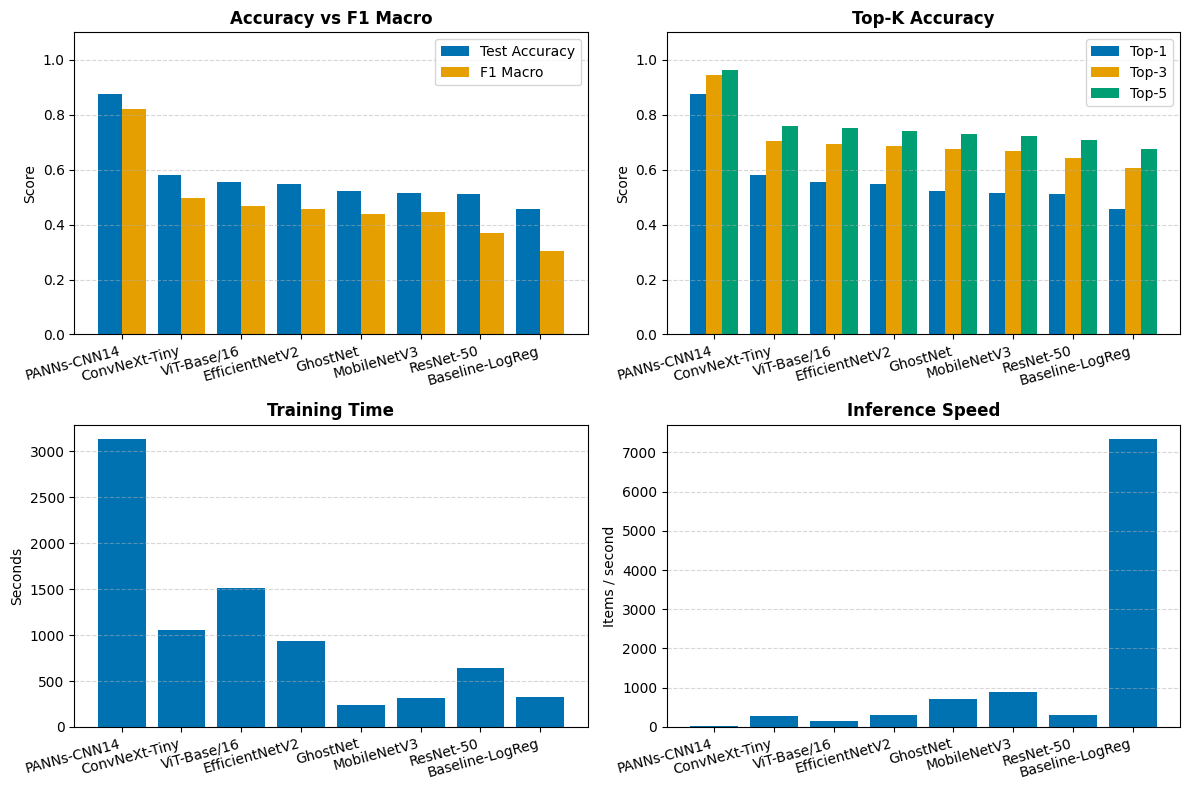

In [51]:
# Okabe-Ito colourblind-friendly palette
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442"]

def bar_chart(ax, series_dict, title, ylabel, ylim=None):
    """Grouped bar chart from {legend_label: pandas.Series}."""
    models = results_df["Model"].tolist()
    x = np.arange(len(models))
    width = 0.8 / len(series_dict)
    for i, (label, series) in enumerate(series_dict.items()):
        offset = (i - (len(series_dict) - 1) / 2) * width
        ax.bar(x + offset, series.fillna(0), width, label=label, color=PALETTE[i])
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    if ylim: ax.set_ylim(*ylim)
    if len(series_dict) > 1: ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

bar_chart(axes[0, 0],
          {"Test Accuracy": results_df["Test Accuracy"], "F1 Macro": results_df["F1 Macro"]},
          "Accuracy vs F1 Macro", "Score", ylim=(0, 1.1)
         )

bar_chart(axes[0, 1],
          {"Top-1": results_df["Top-1 Accuracy"], "Top-3": results_df["Top-3 Accuracy"], "Top-5": results_df["Top-5 Accuracy"]},
          "Top-K Accuracy", "Score", ylim=(0, 1.1)
         )

bar_chart(axes[1, 0], {"Train Time (s)": results_df["Train Time (s)"]}, "Training Time", "Seconds")
bar_chart(axes[1, 1], {"Items/sec": results_df["Items/sec"]}, "Inference Speed", "Items / second")

plt.tight_layout()
plt.show()


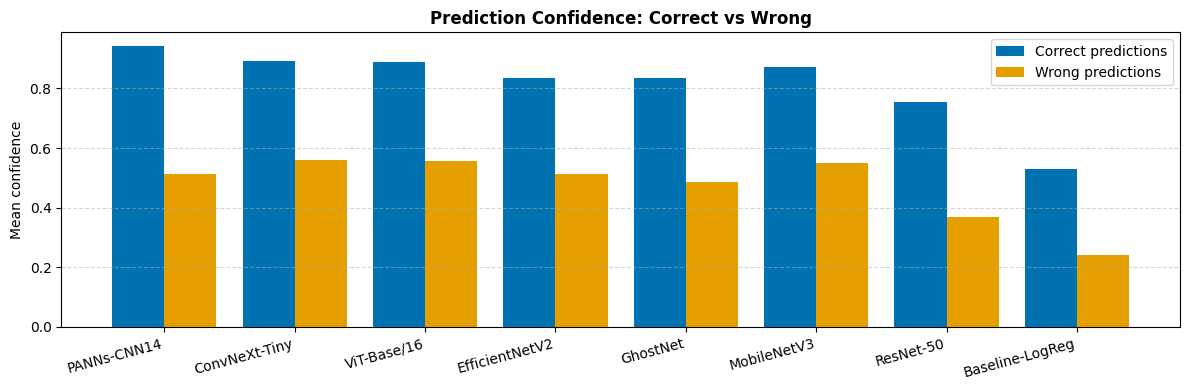

In [50]:
# Confidence
fig, ax = plt.subplots(figsize=(12, 4))
bar_chart(ax,
          {"Correct predictions": results_df["Mean Confidence (Correct)"],
           "Wrong predictions": results_df["Mean Confidence (Wrong)"]},
          "Prediction Confidence: Correct vs Wrong", "Mean confidence"
         )

plt.tight_layout()
plt.show()

### Most Confused Class Pairs

For each model, list the off-diagonal confusion-matrix entries with the highest counts (basically which classes the model mixes up most).


In [30]:
N_PAIRS = 10

for name, art in artifacts.items():
    cm = art["confusion_matrix"]
    rows, cols = np.indices(cm.shape)
    off_diag = rows != cols
    pairs = sorted(
        zip(cm[off_diag], le.classes_[rows[off_diag]], le.classes_[cols[off_diag]]),
        reverse=True,
    )[:N_PAIRS]
    print(f"\nTop {N_PAIRS} most confused pairs :: {name}:")
    display(pd.DataFrame(pairs, columns=["Count", "True Label", "Predicted As"]))



Top 10 most confused pairs :: Baseline-LogReg:


,Count,True Label,Predicted As
0,25,Colluricincla harmonica,Rhipidura leucophrys
1,20,Rhipidura albiscapa,Rhipidura leucophrys
2,16,Rhipidura albiscapa,Colluricincla harmonica
3,16,Dasyurus maculatus,Rhipidura leucophrys
4,16,Acanthiza pusilla,Rhipidura leucophrys
5,15,Rhipidura leucophrys,Colluricincla harmonica
6,15,Cisticola exilis,Rhipidura leucophrys
7,13,Rhipidura leucophrys,Rhipidura albiscapa
8,12,Barnardius zonarius,Rhipidura leucophrys
9,11,Rhipidura albiscapa,Acanthiza pusilla



Top 10 most confused pairs :: GhostNet:


,Count,True Label,Predicted As
0,15,Cophixalus infacetus,Rhipidura albiscapa
1,11,Acanthiza pusilla,Rhipidura albiscapa
2,10,Rhipidura albiscapa,Rhipidura leucophrys
3,10,Rhipidura albiscapa,Colluricincla harmonica
4,10,Philemon citreogularis,Rhipidura leucophrys
5,10,Acanthiza pusilla,Rhipidura leucophrys
6,9,sheowl,wiltur
7,9,Cincloramphus mathewsi,Phylidonyris niger
8,8,Rhipidura leucophrys,Rhipidura albiscapa
9,8,Colluricincla harmonica,Rhipidura albiscapa



Top 10 most confused pairs :: EfficientNetV2:


...

,Count,True Label,Predicted As
0,20,brant,sheowl
1,11,Rhipidura albiscapa,Colluricincla harmonica
2,8,Cophixalus infacetus,Rhipidura albiscapa
3,8,Acanthiza nana,Rhipidura leucophrys
4,7,Rhipidura albiscapa,Rhipidura leucophrys
5,7,Phylidonyris niger,Colluricincla harmonica
6,7,Colluricincla harmonica,Cincloramphus mathewsi
7,7,Cincloramphus mathewsi,Phylidonyris niger
8,6,Rhipidura leucophrys,Phylidonyris niger
9,6,Rhipidura leucophrys,Acanthiza reguloides



Top 10 most confused pairs :: ViT-Base/16:


,Count,True Label,Predicted As
0,18,Cophixalus infacetus,Rhipidura albiscapa
1,15,Rhipidura albiscapa,Colluricincla harmonica
2,11,Rhipidura albiscapa,Rhipidura leucophrys
3,10,Rhipidura leucophrys,Rhipidura albiscapa
4,8,Rhipidura albiscapa,Acanthiza pusilla
5,8,Philemon corniculatus,Colluricincla harmonica
6,8,Cincloramphus mathewsi,Phylidonyris niger
7,8,Acanthiza pusilla,Rhipidura leucophrys
8,7,Rhipidura leucophrys,Acanthiza pusilla
9,7,Phylidonyris niger,Colluricincla harmonica



Top 10 most confused pairs :: PANNs-CNN14:


,Count,True Label,Predicted As
0,7,brant,sheowl
1,6,Philemon corniculatus,Philemon citreogularis
2,5,Falco berigora,Eurystomus orientalis
3,4,Rhipidura leucophrys,Haliastur sphenurus
4,4,Colluricincla harmonica,Barnardius zonarius
5,3,sheowl,brant
6,3,Stomiopera unicolor,Haliastur sphenurus
7,3,Rhipidura leucophrys,Rhipidura rufiventris
8,3,Rhipidura leucophrys,Rhipidura albiscapa
9,3,Manorina melanophrys,Rhipidura rufiventris


### Training Curves

Plot the per-epoch training loss for each deep model.


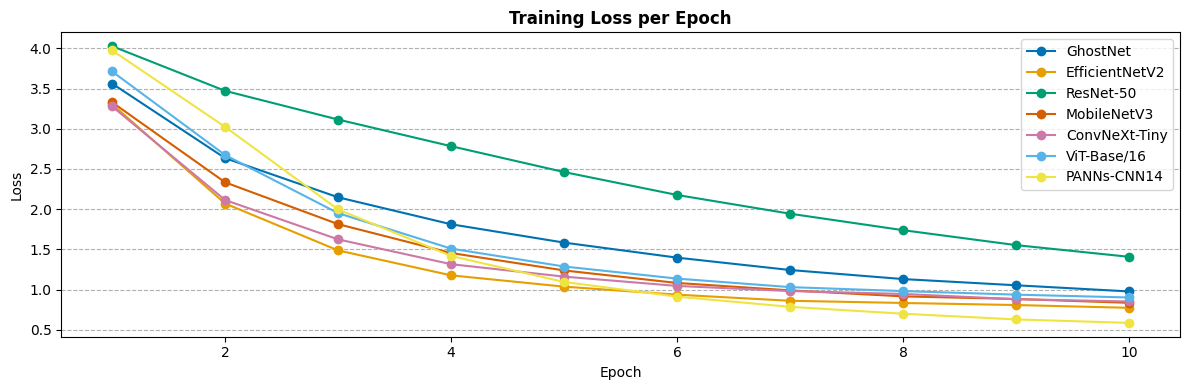

In [33]:
histories = {name: art["history"] for name, art in artifacts.items() if art["history"]}

if histories:
    fig, ax = plt.subplots(figsize=(12, 4))
    for i, (name, hist) in enumerate(histories.items()):
        losses = hist["train_loss"]
        ax.plot(range(1, len(losses) + 1), losses, marker="o", color=PALETTE[i], label=name)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Training Loss per Epoch", fontweight="bold")
    ax.grid(axis="y", linestyle="--")
    ax.legend()
    plt.tight_layout(); plt.show()
else:
    print("No training history found. Run the deep-model benchmarks first.")
